## Task

HappyPaws has collected three datasets over the past year: 
 - "pet_activities.csv" which logs daily activities of pets, 
 - "pet_health.csv" which records vet visits and health issues, and 
 - "users.csv" which contains information about the pet owners. 

Each dataset contains unique identifiers for pets and/or their owners. 

The engineers developing the app currently write code to cross reference all of these data sources. 

They want to make things easier by having a single table with all data included.

Your manager has asked you to write a Python function that cleans and merges these datasets into a single dataset. 

The final dataset should provide a comprehensive view of each pet's activities, health records, and owner information. 
- To test your code, your manager will run only the code `all_pet_data('pet_activities.csv', 'pet_health.csv', 'users.csv')`
- Your `all_pet_data()` function must return a DataFrame, with columns as described below.
- All columns must accurately match the descriptions provided below, including names.

## Data

The data that has been provided has the following structure

![image](image.png)

The function that you write must return data as described below. There should be a unique row for each activity/health visit. 

Where missing values are permitted, they should be in the default Python format.

|Column Name | Description |
|-------|-------|
| pet_id | Unique identifier for each pet. There should not be any missing values.|
| date | The date of the activity recorded or the date of the health visit, in date format. There should not be any missing values.|
| activity_type | The type of activity, one of 'Walking', 'Playing', 'Resting' or for rows that relate to a health visit, the value 'Health'. Missing values are permitted.|
| duration_minutes | The duration of the activity in minutes. For rows that relate to health visits, this should be 0. Missing values for other activities are permitted.|
| issue | The health issue identified or check-up note. For rows that relate to activities, this should be a missing value. Missing values for health activities are permitted.|
| resolution | The outcome or advice given for the issue. For rows that relate to activities, this should be a missing value. Missing values for health activities are permitted.|
| owner_id | Unique identifier for the pet owner. All pets must have an owner.|
| owner_age_group | The age group of the owner (e.g., 18-25, 26-35, etc.). Missing values are permitted.|
| pet_type | The type of pet (e.g., Dog, Cat). Missing values are permitted.|

## Static Analytical Dashboard (Matplotlib & Seaborn)

This dashboard is built directly on the DataFrame returned by `all_pet_data()` — no
extra "summary" dataset is created in between. Each chart below computes what it
needs straight from that DataFrame with a plain one-line `groupby` / `value_counts`,
the way you'd normally do it in a notebook.

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", palette="Set2")

df = pd.read_csv('all_data', parse_dates=['date'])
print(df.shape)
df.head()


(1878, 9)


,pet_id,date,activity_type,duration_minutes,issue,resolution,owner_id,owner_age_group,pet_type
0,9930,2023-08-01,Resting,NaN,NaN,NaN,7016,18-25,Dog
1,3040,2023-07-24,Resting,4.0,NaN,NaN,5637,18-25,Rabbit
2,2381,2023-01-11,Walking,24.0,NaN,NaN,5366,18-25,Rabbit
3,3936,2022-09-15,Walking,73.0,NaN,NaN,7063,26-35,Hamster
4,8989,2023-02-06,Playing,77.0,NaN,NaN,3803,36-45,Dog


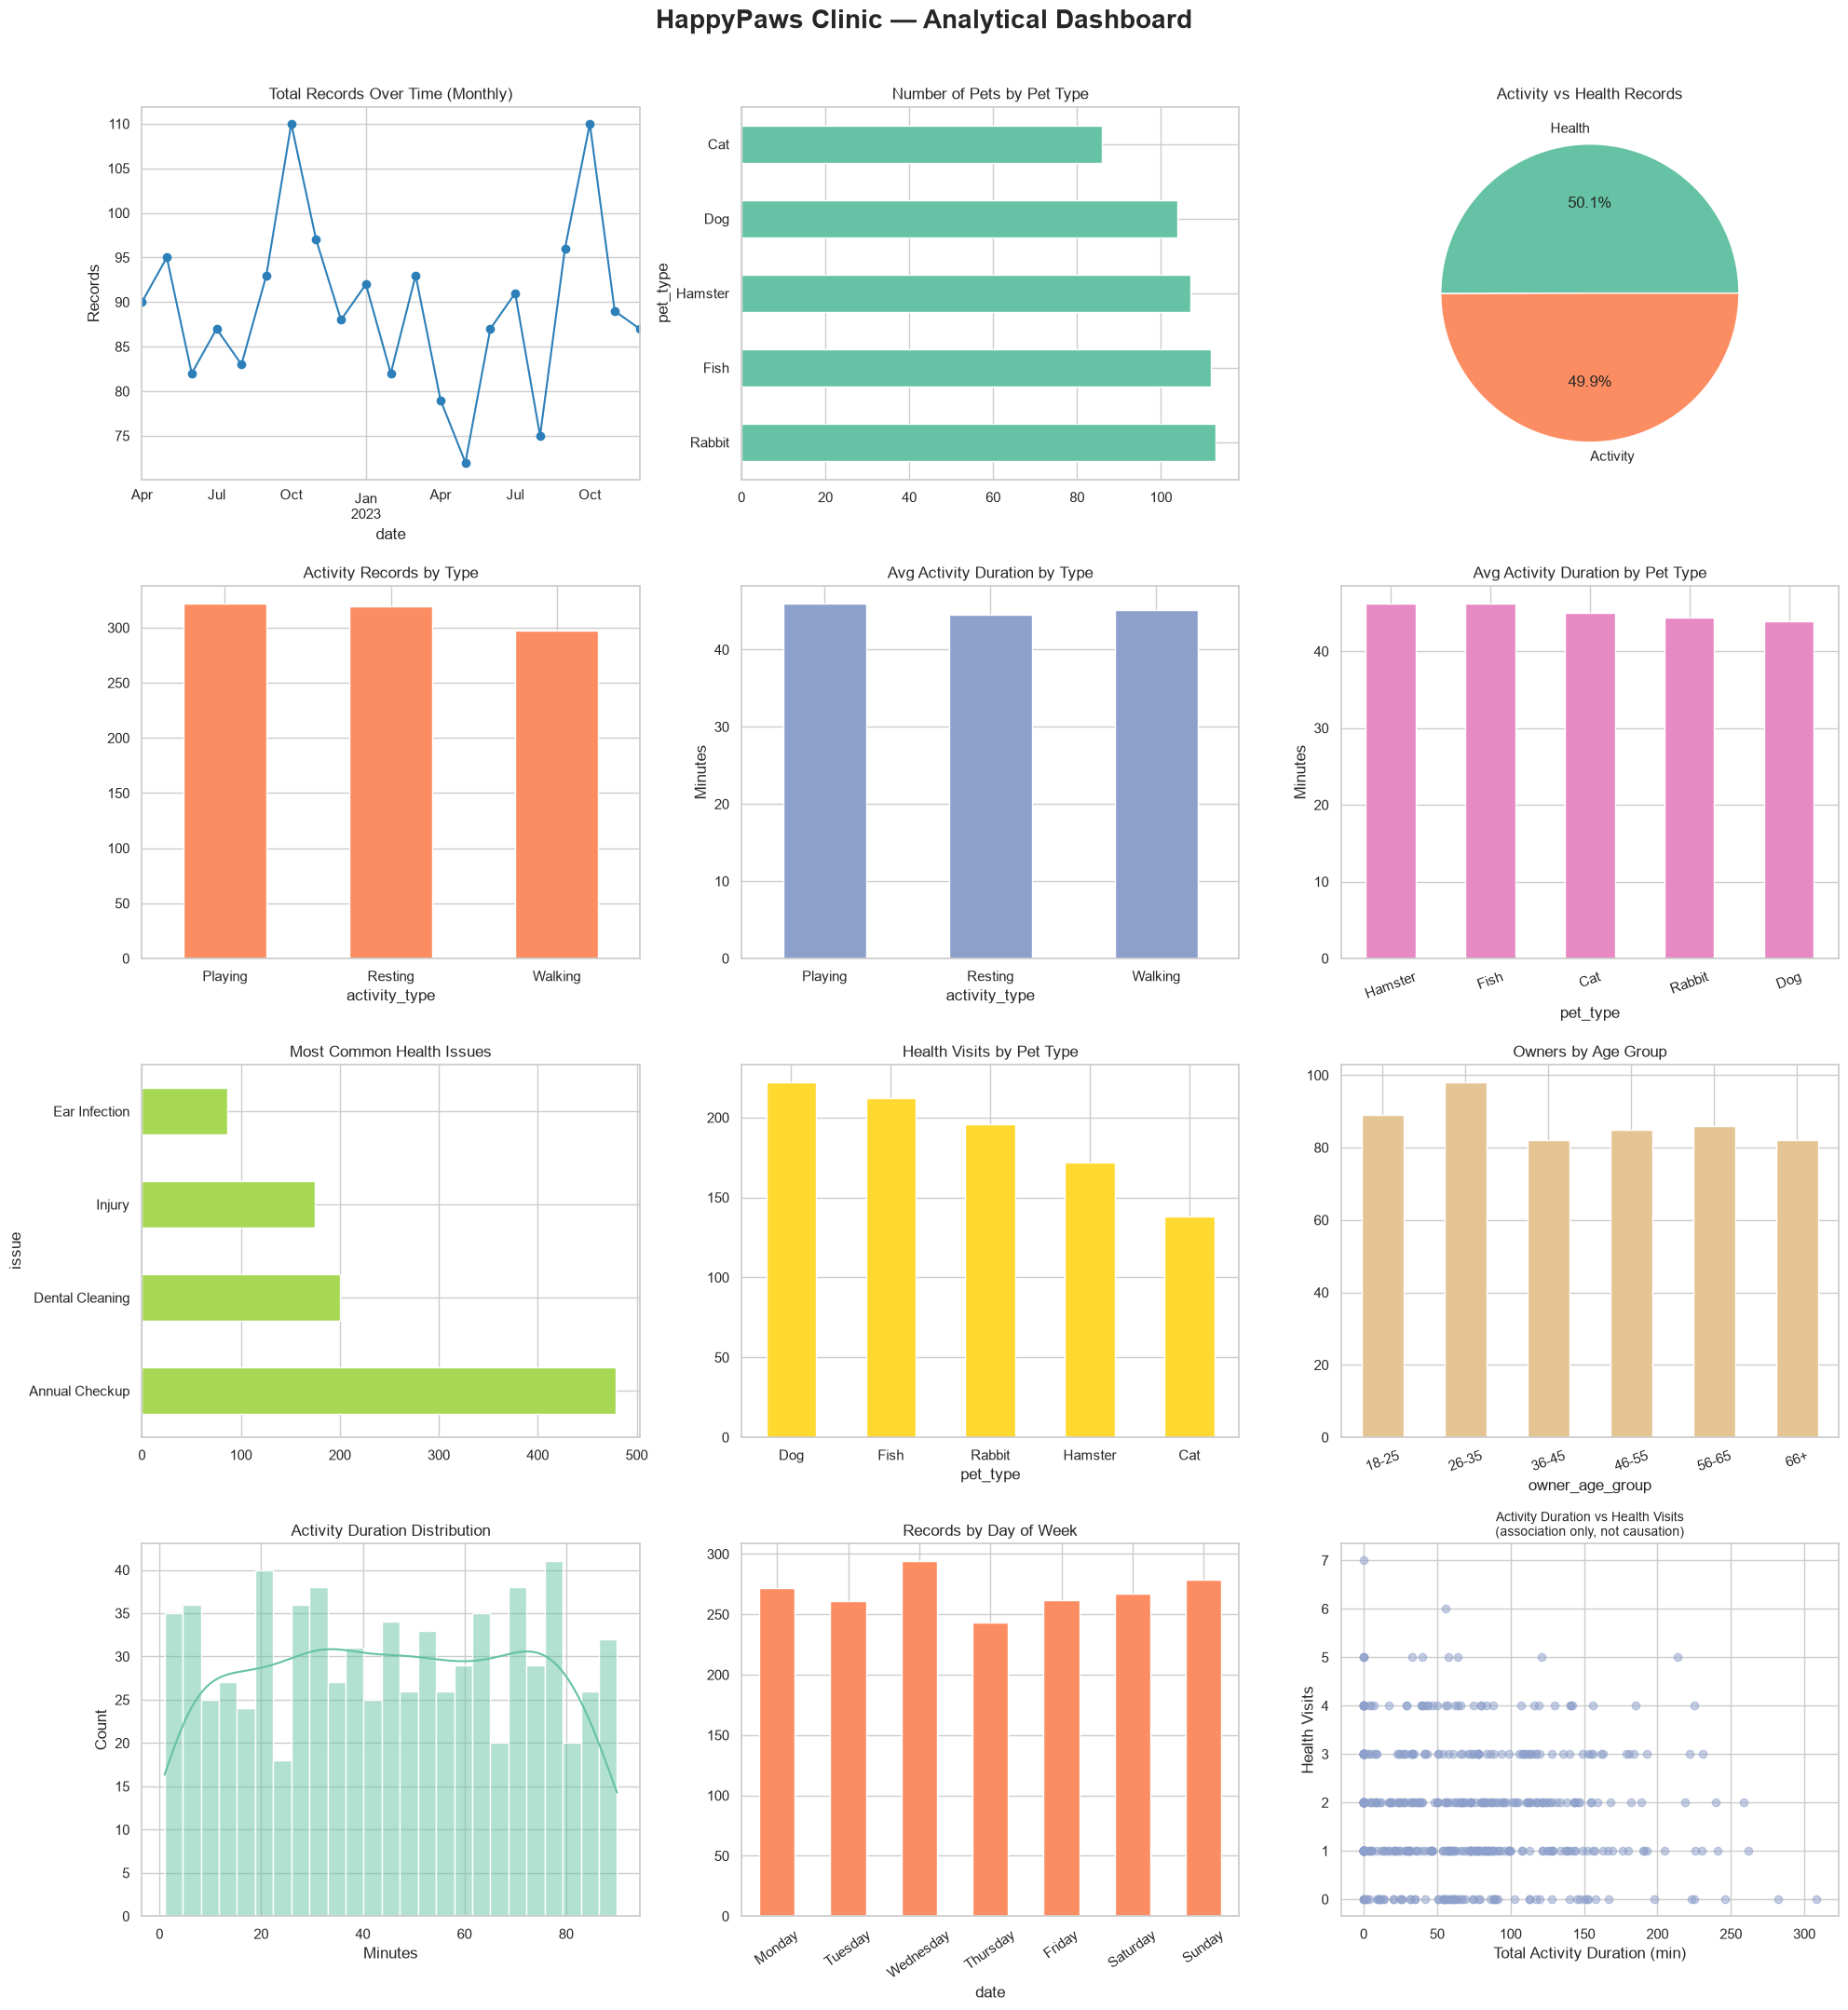

Dashboard saved as happypaws_dashboard.png


In [2]:
# ---- Static dashboard: 12 charts straight off df, nothing pre-aggregated in between ----
fig, axes = plt.subplots(4, 3, figsize=(20, 22))
fig.suptitle("HappyPaws Clinic — Analytical Dashboard", fontsize=20, fontweight="bold")
axes = axes.flatten()

# 1. Records over time (monthly)
df.groupby(df['date'].dt.to_period('M')).size().plot(ax=axes[0], marker='o', color='#2c7fb8')
axes[0].set_title('Total Records Over Time (Monthly)')
axes[0].set_ylabel('Records')

# 2. Number of pets by pet type
df.drop_duplicates('pet_id')['pet_type'].value_counts().plot(kind='barh', ax=axes[1], color='#66c2a5')
axes[1].set_title('Number of Pets by Pet Type')

# 3. Activity vs Health records
df['activity_type'].eq('Health').map({True: 'Health', False: 'Activity'}).value_counts().plot(
    kind='pie', ax=axes[2], autopct='%1.1f%%', ylabel='')
axes[2].set_title('Activity vs Health Records')

# 4. Activity records by activity type (exclude Health rows)
df.loc[df['activity_type'] != 'Health', 'activity_type'].value_counts().plot(kind='bar', ax=axes[3], color='#fc8d62')
axes[3].set_title('Activity Records by Type')
axes[3].tick_params(axis='x', rotation=0)

# 5. Average activity duration by activity type
df.loc[df['activity_type'] != 'Health'].groupby('activity_type')['duration_minutes'].mean().plot(
    kind='bar', ax=axes[4], color='#8da0cb')
axes[4].set_title('Avg Activity Duration by Type')
axes[4].set_ylabel('Minutes')
axes[4].tick_params(axis='x', rotation=0)

# 6. Average activity duration by pet type
df.loc[df['activity_type'] != 'Health'].groupby('pet_type')['duration_minutes'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[5], color='#e78ac3')
axes[5].set_title('Avg Activity Duration by Pet Type')
axes[5].set_ylabel('Minutes')
axes[5].tick_params(axis='x', rotation=20)

# 7. Most common health issues
df.loc[df['activity_type'] == 'Health', 'issue'].value_counts().plot(kind='barh', ax=axes[6], color='#a6d854')
axes[6].set_title('Most Common Health Issues')

# 8. Health visits by pet type
df.loc[df['activity_type'] == 'Health', 'pet_type'].value_counts().plot(kind='bar', ax=axes[7], color='#ffd92f')
axes[7].set_title('Health Visits by Pet Type')
axes[7].tick_params(axis='x', rotation=0)

# 9. Owners by age group
df.drop_duplicates('owner_id')['owner_age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[8], color='#e5c494')
axes[8].set_title('Owners by Age Group')
axes[8].tick_params(axis='x', rotation=20)

# 10. Activity duration distribution
sns.histplot(df.loc[df['activity_type'] != 'Health', 'duration_minutes'].dropna(), bins=25, kde=True, ax=axes[9], color='#66c2a5')
axes[9].set_title('Activity Duration Distribution')
axes[9].set_xlabel('Minutes')

# 11. Records by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['date'].dt.day_name().value_counts().reindex(day_order).plot(kind='bar', ax=axes[10], color='#fc8d62')
axes[10].set_title('Records by Day of Week')
axes[10].tick_params(axis='x', rotation=35)

# 12. Total activity duration vs number of health visits, per pet (observed association only)
activity_duration_per_pet = df.loc[df['activity_type'] != 'Health'].groupby('pet_id')['duration_minutes'].sum()
health_visits_per_pet = df.loc[df['activity_type'] == 'Health'].groupby('pet_id').size()
axes[11].scatter(activity_duration_per_pet.reindex(df['pet_id'].unique()).fillna(0),
                  health_visits_per_pet.reindex(df['pet_id'].unique()).fillna(0),
                  alpha=0.5, color='#8da0cb')
axes[11].set_title('Activity Duration vs Health Visits\n(association only, not causation)', fontsize=10)
axes[11].set_xlabel('Total Activity Duration (min)')
axes[11].set_ylabel('Health Visits')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('happypaws_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Dashboard saved as happypaws_dashboard.png")
